# Ejercicio 8 - Interpretación y explicabilidad

Se interpreta el mejor modelo mediante importancia global y SHAP sobre una muestra reproducible.

## 0. Verificación del trabajo previo (gate)

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display
from src.evaluacion import verificar_evaluacion
from src.validacion import verificar_validacion

verificar_evaluacion()
verificar_validacion()
print('Gate previo correcto.')

Gate previo correcto.


## 1-2. Importancia global y resumen SHAP

La muestra SHAP contiene 5,000 filas elegidas de forma determinística y equiespaciada.

,modelo,variable,importancia_modelo,importancia_modelo_normalizada,shap_media_absoluta,shap_media_absoluta_normalizada,correlacion_valor_shap,direccion_efecto,n_muestra_shap
0,gradient_boosting,B03,0.023335,0.023335,3.131013,0.208951,0.033954,efecto no monotono o debil,5000
1,gradient_boosting,lago_amatitlan,0.553806,0.553806,2.100153,0.140156,0.569267,valores altos aumentan la prediccion,5000
2,gradient_boosting,y_utm,0.000801,0.000801,1.814416,0.121087,-0.329000,valores altos disminuyen la prediccion,5000
3,gradient_boosting,B08,0.002080,0.002080,1.649864,0.110105,0.896866,valores altos aumentan la prediccion,5000
4,gradient_boosting,x_utm,0.000903,0.000903,1.279798,0.085409,0.444585,valores altos aumentan la prediccion,5000
5,gradient_boosting,ndwi_vecindad_3x3,0.000982,0.000982,1.144051,0.076349,-0.629750,valores altos disminuyen la prediccion,5000
6,gradient_boosting,dist_orilla_m,0.000265,0.000265,0.784714,0.052369,-0.706304,valores altos disminuyen la prediccion,5000
7,gradient_boosting,dia_anio_cos,0.003838,0.003838,0.601422,0.040136,-0.758066,valores altos disminuyen la prediccion,5000
8,gradient_boosting,ndwi,0.001015,0.001015,0.468837,0.031288,-0.690132,valores altos disminuyen la prediccion,5000
9,gradient_boosting,dist_centroide_m,0.000430,0.000430,0.461134,0.030774,0.489758,valores altos aumentan la prediccion,5000


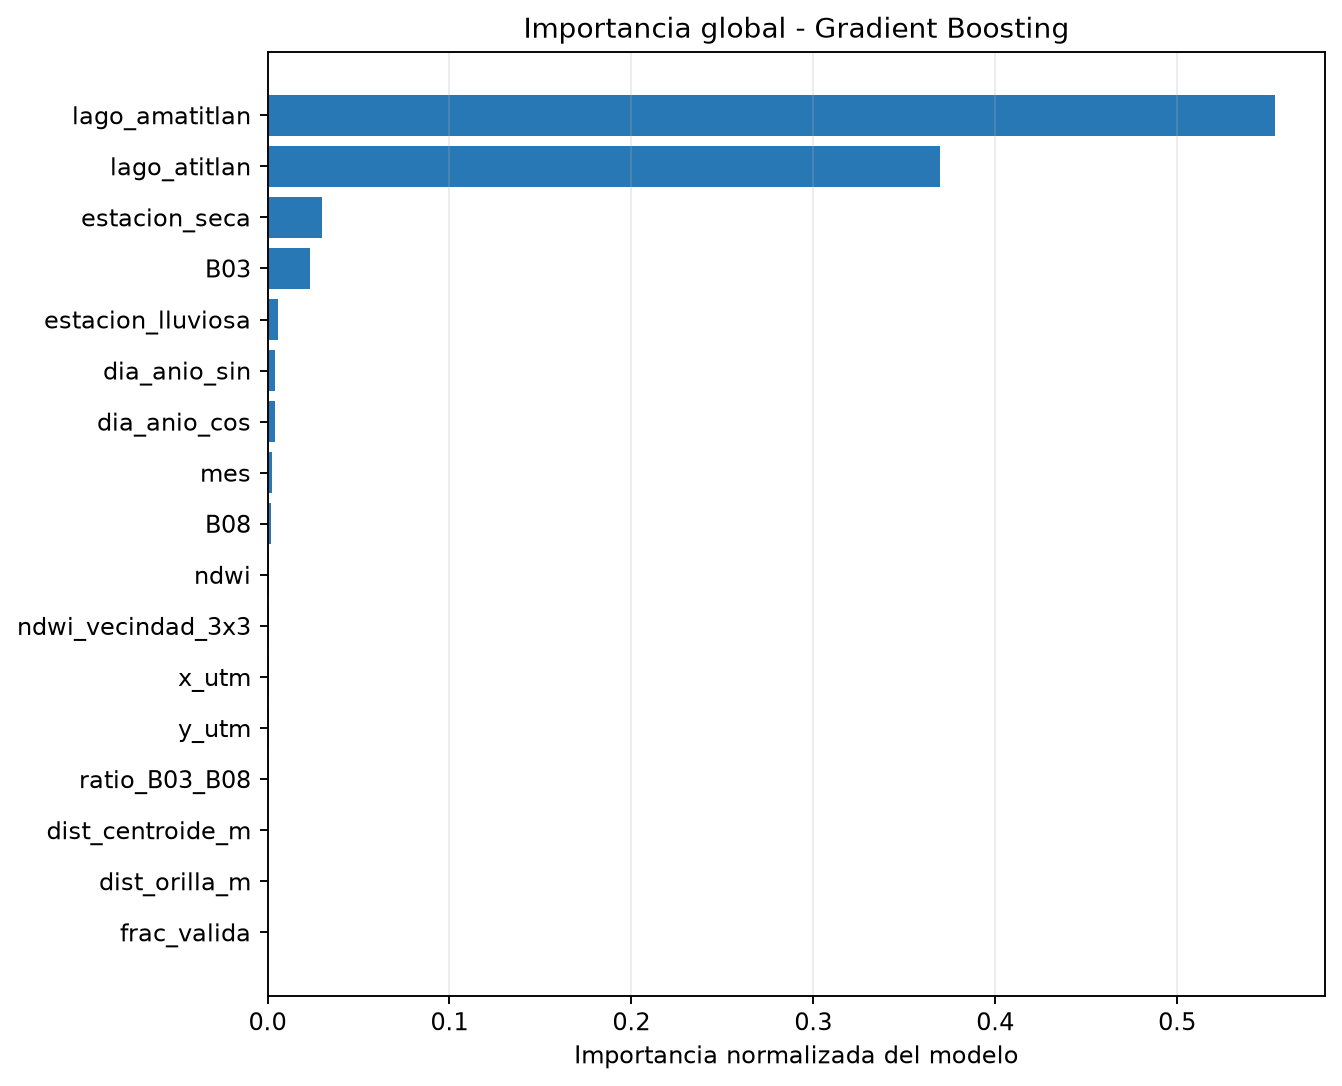

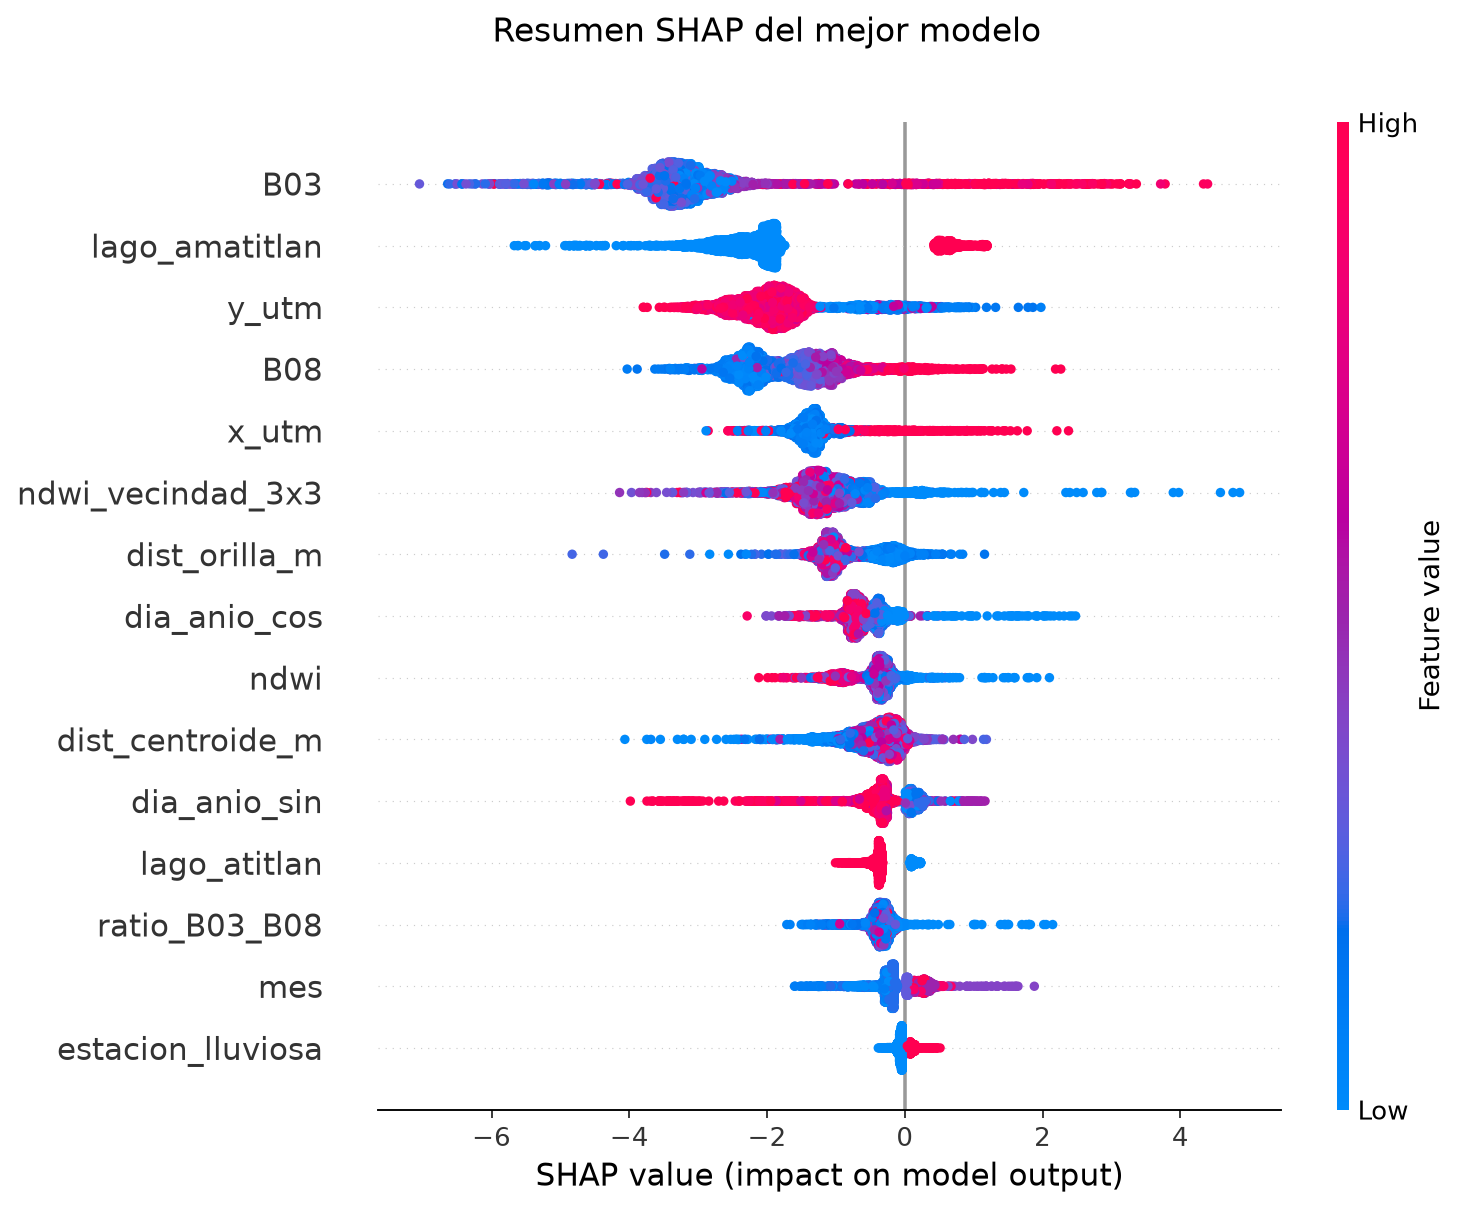

In [2]:
from src.interpretabilidad import analizar, verificar

resumen = analizar()
verificar()
tabla = pd.read_csv(resumen['tabla'])
display(tabla.head(10))
display(Image(filename=str(resumen['figura_importancia'])))
display(Image(filename=str(resumen['figura_shap'])))

## 3. Variables influyentes y lectura ambiental

B03 aporta la mayor magnitud SHAP, pero su efecto no es monótono. B08 alto tiende a elevar la predicción; NDWI y NDWI de vecindad altos tienden a reducirla. La distancia a la orilla tiene dirección negativa, por lo que las celdas costeras reciben mayor riesgo. La identidad y las coordenadas del lago describen contexto del dominio, no mecanismos causales; su influencia concuerda con la mala transferencia entre lagos.

In [3]:
display(tabla[['variable', 'shap_media_absoluta_normalizada', 'correlacion_valor_shap', 'direccion_efecto']].head(10))

,variable,shap_media_absoluta_normalizada,correlacion_valor_shap,direccion_efecto
0,B03,0.208951,0.033954,efecto no monotono o debil
1,lago_amatitlan,0.140156,0.569267,valores altos aumentan la prediccion
2,y_utm,0.121087,-0.329000,valores altos disminuyen la prediccion
3,B08,0.110105,0.896866,valores altos aumentan la prediccion
4,x_utm,0.085409,0.444585,valores altos aumentan la prediccion
5,ndwi_vecindad_3x3,0.076349,-0.629750,valores altos disminuyen la prediccion
6,dist_orilla_m,0.052369,-0.706304,valores altos disminuyen la prediccion
7,dia_anio_cos,0.040136,-0.758066,valores altos disminuyen la prediccion
8,ndwi,0.031288,-0.690132,valores altos disminuyen la prediccion
9,dist_centroide_m,0.030774,0.489758,valores altos aumentan la prediccion
